In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import json
import pickle

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

# Set project root for module imports if necessary
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

# Seaborn style
sns.set(style="whitegrid")

In [2]:
def prepare_data(path="../data/processed/consumer_complaints_final.csv", vocab_size=25000, max_len=250):
    """
    Loads, preprocesses, and splits the data for sentiment classification.
    """
    df = pd.read_csv(path)
    df = df[df['text_cleaned'].notna()].copy()

    # Encode sentiment labels
    le = LabelEncoder()
    df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

    # Separate features
    X_text = df['text_cleaned']
    X_struct = df[['text_length', 'timely_response_binary', 'product_dispute_rate',
                   'company_dispute_rate', 'keyword_flag']].values.astype(np.float32)
    y = df['sentiment_encoded']

    # Tokenize and pad text
    tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_text)
    X_seq = pad_sequences(tokenizer.texts_to_sequences(X_text), maxlen=max_len)

    # Create train, validation, and test splits (70-15-15)
    X_seq_train, X_seq_temp, X_struct_train, X_struct_temp, y_train, y_temp = train_test_split(
        X_seq, X_struct, y, test_size=0.3, stratify=y, random_state=42
    )
    X_seq_val, X_seq_test, X_struct_val, X_struct_test, y_val, y_test = train_test_split(
        X_seq_temp, X_struct_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    return (X_seq_train, X_struct_train, y_train,
            X_seq_val, X_struct_val, y_val,
            X_seq_test, X_struct_test, y_test,
            tokenizer, le)

# Load the data
(X_seq_train, X_struct_train, y_train,
 X_seq_val, X_struct_val, y_val,
 X_seq_test, X_struct_test, y_test,
 tokenizer, le) = prepare_data()

print("Data prepared successfully!")
print(f"Training data shape: {X_seq_train.shape}")
print(f"Validation data shape: {X_seq_val.shape}")
print(f"Test data shape: {X_seq_test.shape}")

Data prepared successfully!
Training data shape: (46764, 250)
Validation data shape: (10021, 250)
Test data shape: (10021, 250)


In [3]:
def build_hypermodel(hp):
    """
    Builds a Keras model with a defined hyperparameter search space.
    """
    # Hyperparameters to tune
    embedding_dim = hp.Int('embedding_dim', min_value=64, max_value=256, step=32)
    lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    # Model Architecture
    text_input = Input(shape=(250,), name="text_input")
    struct_input = Input(shape=(5,), name="struct_input")

    x = Embedding(input_dim=25000, output_dim=embedding_dim)(text_input)
    x = Bidirectional(LSTM(units=lstm_units))(x)
    x = Dropout(rate=dropout_rate)(x)

    merged = Concatenate()([x, struct_input])
    merged = Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32), activation='relu')(merged)
    merged = Dropout(rate=dropout_rate)(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[text_input, struct_input], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [4]:
# Initialize the tuner
tuner = kt.RandomSearch(
    build_hypermodel,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to test
    executions_per_trial=1, # Number of times to train each model
    directory='../models/hyper_tuning', # Directory to save results
    project_name='sentiment_classification'
)

# Callback to stop training early if no improvement
stop_early = EarlyStopping(monitor='val_loss', patience=5)

# Start the search
print("Starting hyperparameter tuning...")
tuner.search(
    {"text_input": X_seq_train, "struct_input": X_struct_train}, y_train,
    epochs=20,
    validation_data=({"text_input": X_seq_val, "struct_input": X_struct_val}, y_val),
    callbacks=[stop_early]
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nHyperparameter search complete.")

Trial 10 Complete [00h 09m 24s]
val_accuracy: 0.9370322227478027

Best val_accuracy So Far: 0.9414229989051819
Total elapsed time: 05h 42m 09s

Hyperparameter search complete.


In [5]:
print(f"""
The optimal hyperparameters are:
- Embedding Dimension: {best_hps.get('embedding_dim')}
- LSTM Units: {best_hps.get('lstm_units')}
- Dense Units: {best_hps.get('dense_units')}
- Dropout Rate: {best_hps.get('dropout_rate')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

# Save the best hyperparameters to a file
with open("../outputs/best_hyperparameters.json", "w") as f:
    json.dump(best_hps.values, f, indent=2)


The optimal hyperparameters are:
- Embedding Dimension: 192
- LSTM Units: 64
- Dense Units: 128
- Dropout Rate: 0.30000000000000004
- Learning Rate: 0.0001



In [6]:
# Building the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)

# Computing class weights to handle imbalance during final training
class_weights = dict(
    zip(np.unique(y_train),
        compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train))
)

# Callbacks for final training
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

print("\nTraining the final model with the best hyperparameters...")
history = model.fit(
    {"text_input": X_seq_train, "struct_input": X_struct_train}, y_train,
    validation_data=({"text_input": X_seq_val, "struct_input": X_struct_val}, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, lr_schedule],
    verbose=2
)
print("\nFinal model training complete.")


Training the final model with the best hyperparameters...
Epoch 1/30
731/731 - 60s - 82ms/step - accuracy: 0.4035 - loss: 9.4961 - val_accuracy: 0.4594 - val_loss: 2.2980 - learning_rate: 1.0000e-04
Epoch 2/30
731/731 - 64s - 87ms/step - accuracy: 0.4529 - loss: 5.1623 - val_accuracy: 0.5013 - val_loss: 1.7563 - learning_rate: 1.0000e-04
Epoch 3/30
731/731 - 72s - 99ms/step - accuracy: 0.4999 - loss: 2.9338 - val_accuracy: 0.5956 - val_loss: 1.1887 - learning_rate: 1.0000e-04
Epoch 4/30
731/731 - 82s - 112ms/step - accuracy: 0.5495 - loss: 1.7510 - val_accuracy: 0.6586 - val_loss: 0.7955 - learning_rate: 1.0000e-04
Epoch 5/30
731/731 - 81s - 110ms/step - accuracy: 0.6246 - loss: 1.0825 - val_accuracy: 0.7307 - val_loss: 0.6561 - learning_rate: 1.0000e-04
Epoch 6/30
731/731 - 81s - 111ms/step - accuracy: 0.7071 - loss: 0.7143 - val_accuracy: 0.7714 - val_loss: 0.5408 - learning_rate: 1.0000e-04
Epoch 7/30
731/731 - 81s - 111ms/step - accuracy: 0.7571 - loss: 0.5400 - val_accuracy: 0.77

In [7]:
# Evaluate on the test set
y_pred_prob = model.predict({"text_input": X_seq_test, "struct_input": X_struct_test})
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate and save the classification report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
with open("../outputs/sentiment_accuracy_tuned.txt", "w") as f:
    json.dump(report, f, indent=2)

# Save the final tuned model
model.save("../models/sentiment_model_tuned.keras")

# Save the tokenizer and label encoder
with open("../outputs/tokenizer_sentiment.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("../outputs/label_encoder_sentiment.pkl", "wb") as f:
    pickle.dump(le, f)
    
print("Tuned sentiment model and artifacts saved successfully!")

314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Tuned sentiment model and artifacts saved successfully!


,precision,recall,f1-score,support
extreme_negative,0.972,0.946,0.959,2695.000
negative,0.879,0.887,0.883,3943.000
neutral,0.885,0.893,0.889,3383.000
accuracy,0.905,0.905,0.905,0.905
macro avg,0.912,0.909,0.910,10021.000
weighted avg,0.906,0.905,0.905,10021.000


<Figure size 1000x400 with 0 Axes>

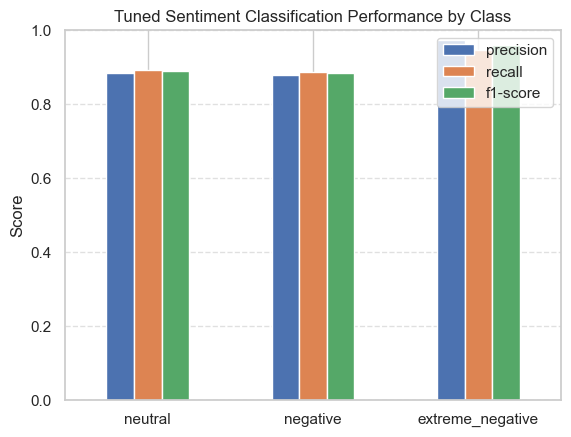

In [8]:
# Load and display the classification report
report_df = pd.DataFrame(report).T.round(3)
display(report_df)

# Plot the key performance metrics
plt.figure(figsize=(10, 4))
report_df.loc[["neutral", "negative", "extreme_negative"], ["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Tuned Sentiment Classification Performance by Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [11]:
# Load metrics report
import json
with open("../outputs/sentiment_accuracy_tuned.txt", "r") as f:
    report = json.load(f)
    
# Convert classification report to DataFrame
report_df = pd.DataFrame(report).T
report_df = report_df.round(3)
display(report_df)

,precision,recall,f1-score,support
extreme_negative,0.972,0.946,0.959,2695.000
negative,0.879,0.887,0.883,3943.000
neutral,0.885,0.893,0.889,3383.000
accuracy,0.905,0.905,0.905,0.905
macro avg,0.912,0.909,0.910,10021.000
weighted avg,0.906,0.905,0.905,10021.000
